In [3]:
import re
import pandas as pd

def analyze_z3_code(code: str):
    if not isinstance(code, str) or not code.strip():
        return None

    # 計算變數數量
    num_reals = len(re.findall(r'=\s*Real\(', code))
    num_ints = len(re.findall(r'=\s*Int\(', code))
    num_bools = len(re.findall(r'=\s*Bool\(', code))

    # 計算 opt.add_soft
    softs_match = re.search(r'softs\s*=\s*\[(.*?)\]', code, re.S)
    num_softs = 0
    if softs_match:
        block = softs_match.group(1)
        num_softs = len(re.findall(r'^\s*\(', block, re.M))

    # 計算 assert_and_track
    num_asserts = len(re.findall(r'opt\.assert_and_track\s*\(', code))

    # 計算 opt.add(...)
    add_calls = re.findall(r'opt\.add\s*\((.*?)\)', code, re.S)
    num_adds = 0
    for call in add_calls:
        # opt.add 可以有多個條件，用逗號分隔
        args = [a for a in re.split(r',(?![^\[\]]*\])', call) if a.strip()]
        num_adds += len(args)

    # 特殊處理 for v in [...] loop
    loop_match = re.search(r'for\s+v\s+in\s*\[(.*?)\]:\s*\n\s*opt\.add', code, re.S)
    if loop_match:
        items = [x.strip() for x in loop_match.group(1).replace("\n", " ").split(",") if x.strip()]
        num_adds += len(items) - 1  # 已經算過一次，補差額

    # 總數
    num_hard = num_adds + num_asserts
    total_constraints = num_hard + num_softs

    return {
        "Real": num_reals,
        "Int": num_ints,
        "Bool": num_bools,
        "Total_Variables": num_reals + num_ints + num_bools,
        "Hard": num_hard,
        "Soft": num_softs,
        "Total_Constraints": total_constraints,
        "Hard_Ratio": round(num_hard / total_constraints, 3) if total_constraints > 0 else 0,
        "Soft_Ratio": round(num_softs / total_constraints, 3) if total_constraints > 0 else 0
    }

def process_excel(filename, column_name, output_file="analysis_results.xlsx"):
    df = pd.read_excel(filename)

    results = []
    for i, code in enumerate(df[column_name]):
        stats = analyze_z3_code(code)
        if stats:
            stats["Case_Index"] = i + 1
            results.append(stats)

    result_df = pd.DataFrame(results)

    # 計算總體統計（平均、最小、最大、標準差）
    summary = result_df.drop(columns=["Case_Index"]).agg(["mean", "min", "max", "std"])
    summary.index = ["Average", "Min", "Max", "Std"]

    # 輸出到 Excel：兩張 sheet
    with pd.ExcelWriter(output_file) as writer:
        result_df.to_excel(writer, sheet_name="Case_Details", index=False)
        summary.to_excel(writer, sheet_name="Summary")

    print(f"分析完成，結果已輸出到 {output_file}")

# === 使用方式 ===
# 假設你的 Excel 檔叫 "cases.xlsx"，程式碼欄位名稱叫 "code"
process_excel("combine_0522.xlsx", "程式碼")


分析完成，結果已輸出到 analysis_results.xlsx


In [10]:
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


In [16]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_distributions(result_df, sheet_name="All"):
    # Histogram: Constraints distribution
    plt.figure(figsize=(8,5))
    plt.hist(result_df["Total_Constraints"], bins=15, alpha=0.7, label="Total")
    plt.hist(result_df["Hard"], bins=15, alpha=0.7, label="Hard")
    plt.hist(result_df["Soft"], bins=15, alpha=0.7, label="Soft")
    plt.xlabel("Number of Constraints")
    plt.ylabel("Number of Cases")
    plt.title(f"{sheet_name} - Constraints Distribution")
    plt.legend()
    plt.show()

    # Boxplot: Variables vs Constraints
    plt.figure(figsize=(8,5))
    result_df[["Total_Variables", "Total_Constraints"]].boxplot()
    plt.title(f"{sheet_name} - Variables vs Constraints (Boxplot)")
    plt.ylabel("Count")
    plt.show()

    # Scatter plot: Variables vs Constraints
    plt.figure(figsize=(6,6))
    plt.scatter(result_df["Total_Variables"], result_df["Total_Constraints"], alpha=0.6)
    plt.xlabel("Number of Variables")
    plt.ylabel("Number of Constraints")
    plt.show()


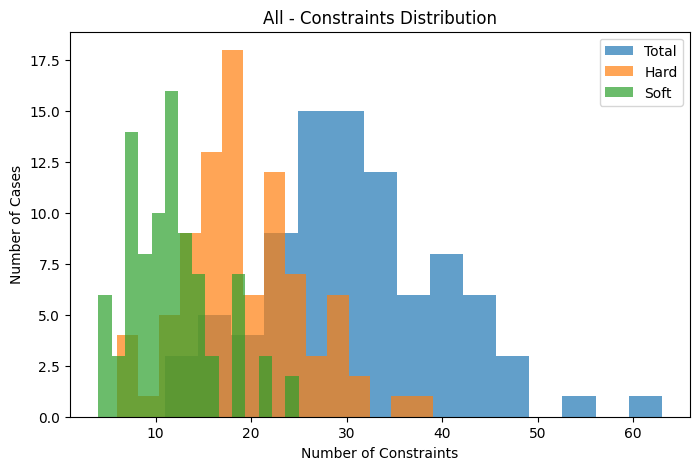

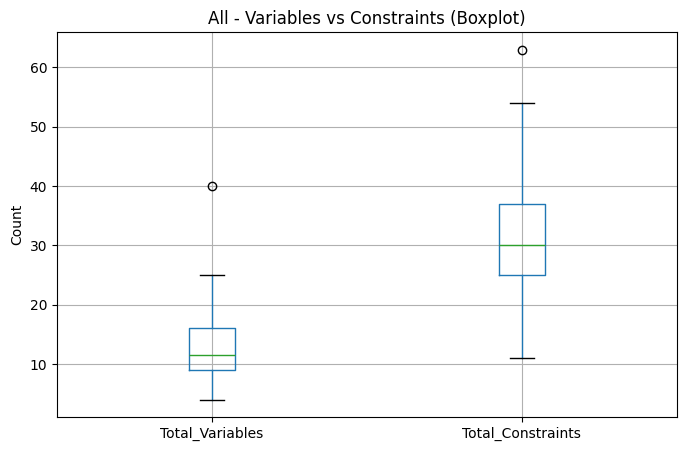

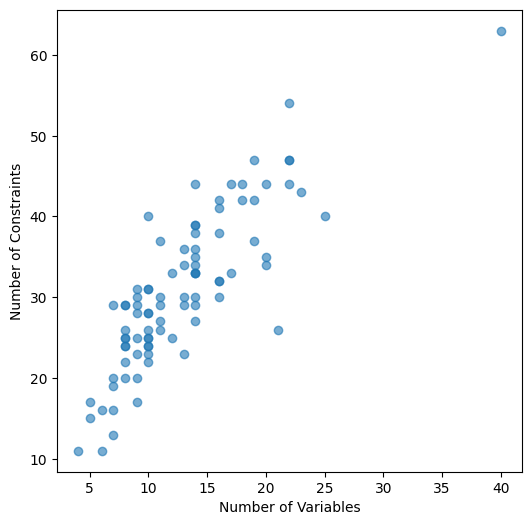

In [17]:
df = pd.read_excel("analysis_results.xlsx")
plot_distributions(df)

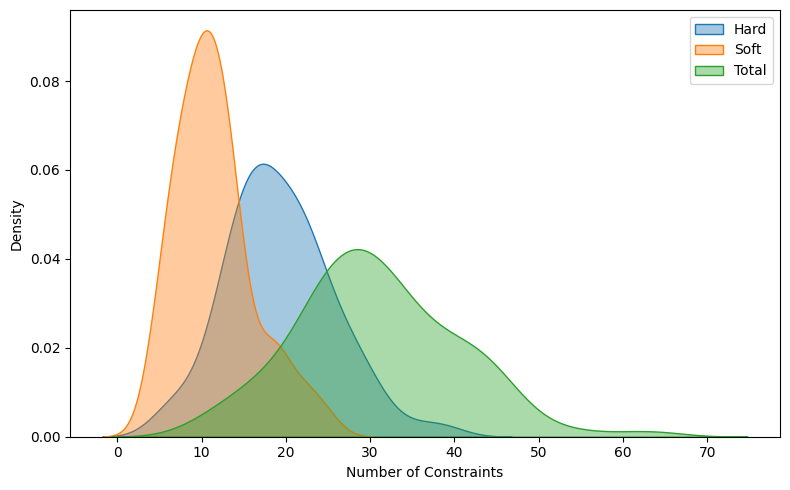

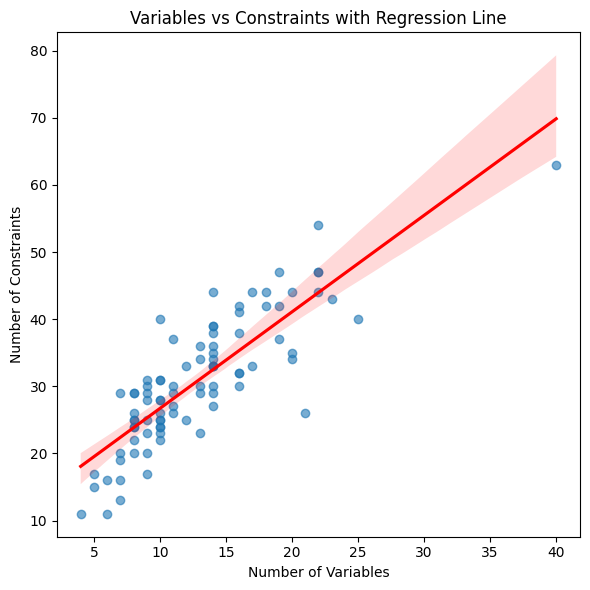

/var/folders/cw/8qbdsql965sf3k7z_6zv0v600000gn/T/ipykernel_13698/2241200034.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Variable Type", y="Count", data=var_types_sum, palette="Set2")


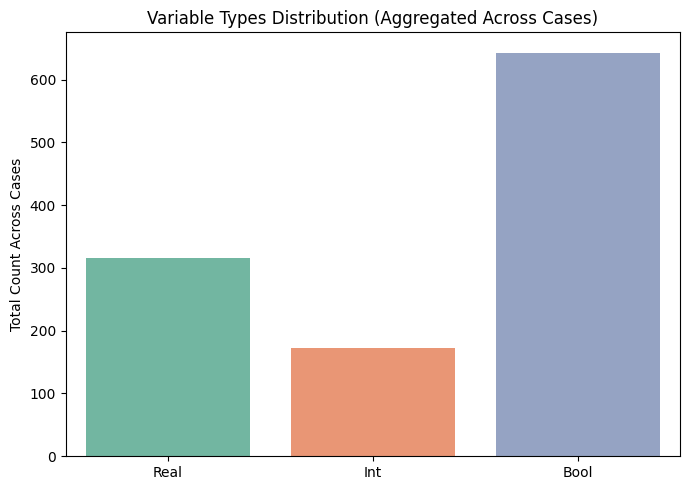

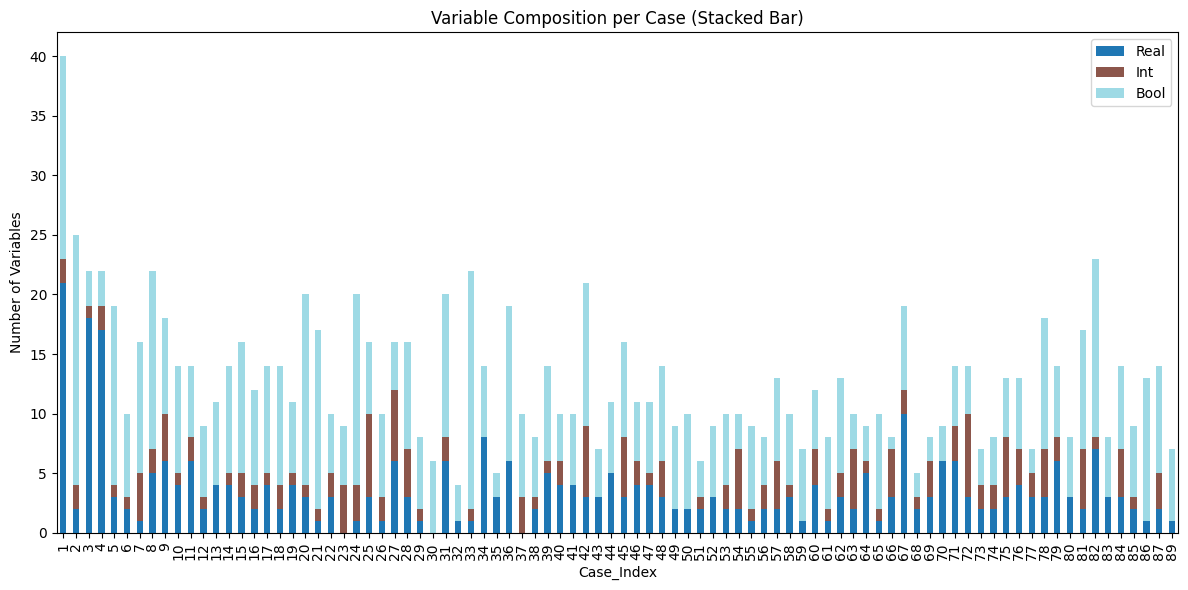

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_analysis(file_path, sheet_name="Case_Details"):
    # 讀取 Excel
    df = pd.read_excel(file_path, sheet_name=sheet_name)

    # 確保數據為 numeric
    numeric_cols = ["Hard", "Soft", "Total_Constraints", "Total_Variables", "Real", "Int", "Bool"]
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    # === 圖1: KDE 分布圖 (Constraints) ===
    plt.figure(figsize=(8,5))
    sns.kdeplot(x=df["Hard"].dropna(), label="Hard", fill=True, alpha=0.4)
    sns.kdeplot(x=df["Soft"].dropna(), label="Soft", fill=True, alpha=0.4)
    sns.kdeplot(x=df["Total_Constraints"].dropna(), label="Total", fill=True, alpha=0.4)
    plt.xlabel("Number of Constraints")
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # === 圖2: 散佈圖 + 迴歸線 ===
    plt.figure(figsize=(6,6))
    sns.regplot(x="Total_Variables", y="Total_Constraints", data=df,
                scatter_kws={'alpha':0.6}, line_kws={"color":"red"})
    plt.xlabel("Number of Variables")
    plt.ylabel("Number of Constraints")
    plt.title("Variables vs Constraints with Regression Line")
    plt.tight_layout()
    plt.show()

    # === 圖3: 總體變數類型分布 (Barplot) ===
    if {"Real","Int","Bool"}.issubset(df.columns):
        var_types_sum = df[["Real","Int","Bool"]].sum().reset_index()
        var_types_sum.columns = ["Variable Type", "Count"]
        plt.figure(figsize=(7,5))
        sns.barplot(x="Variable Type", y="Count", data=var_types_sum, palette="Set2")
        plt.title("Variable Types Distribution (Aggregated Across Cases)")
        plt.ylabel("Total Count Across Cases")
        plt.xlabel("")
        plt.tight_layout()
        plt.show()

        # === 圖4: 每個案例變數類型組成 (Stacked Bar) ===
        df[["Case_Index","Real","Int","Bool"]].set_index("Case_Index").plot(
            kind="bar", stacked=True, figsize=(12,6), colormap="tab20"
        )
        plt.ylabel("Number of Variables")
        plt.title("Variable Composition per Case (Stacked Bar)")
        plt.tight_layout()
        plt.show()

# 使用範例
plot_analysis("analysis_results.xlsx", sheet_name="Case_Details")
